In [2]:
import seaborn as sns

df = sns.load_dataset('iris')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: >

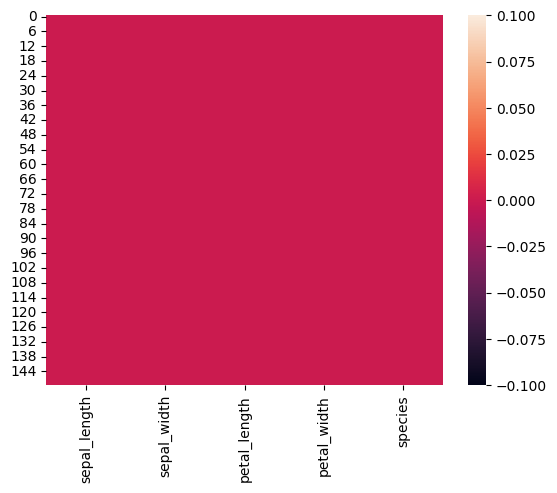

In [5]:
#결측치 시각화 하기
sns.heatmap(df.isnull())

In [7]:
import numpy as np

## 어떤 방법이 가장 좋을까?
## 인위적으로 일부 데이터에 결측치를 생성
np.random.seed(1234)  # 결과의 일관성을 위한 seed 설정
for _ in range(100):  # 100번의 반복으로 결측치를 생성
    i, j = np.random.randint(0, df.shape[0]), np.random.randint(0, df.shape[1])
    df.iat[i, j] = np.nan

print(df.isnull().sum())

sepal_length    18
sepal_width     20
petal_length    17
petal_width     15
species         21
dtype: int64


<Axes: >

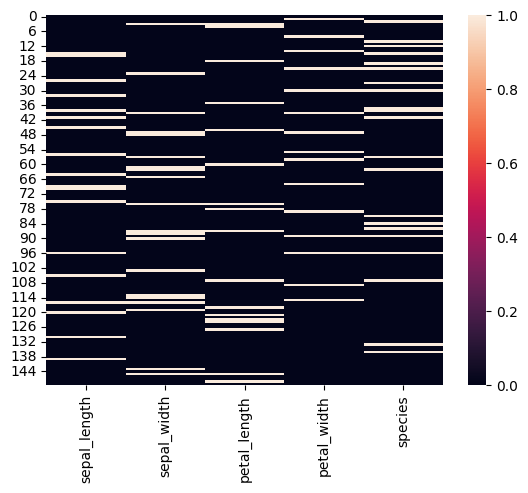

In [8]:
sns.heatmap(df.isnull())

In [10]:
import matplotlib.pyplot as plt

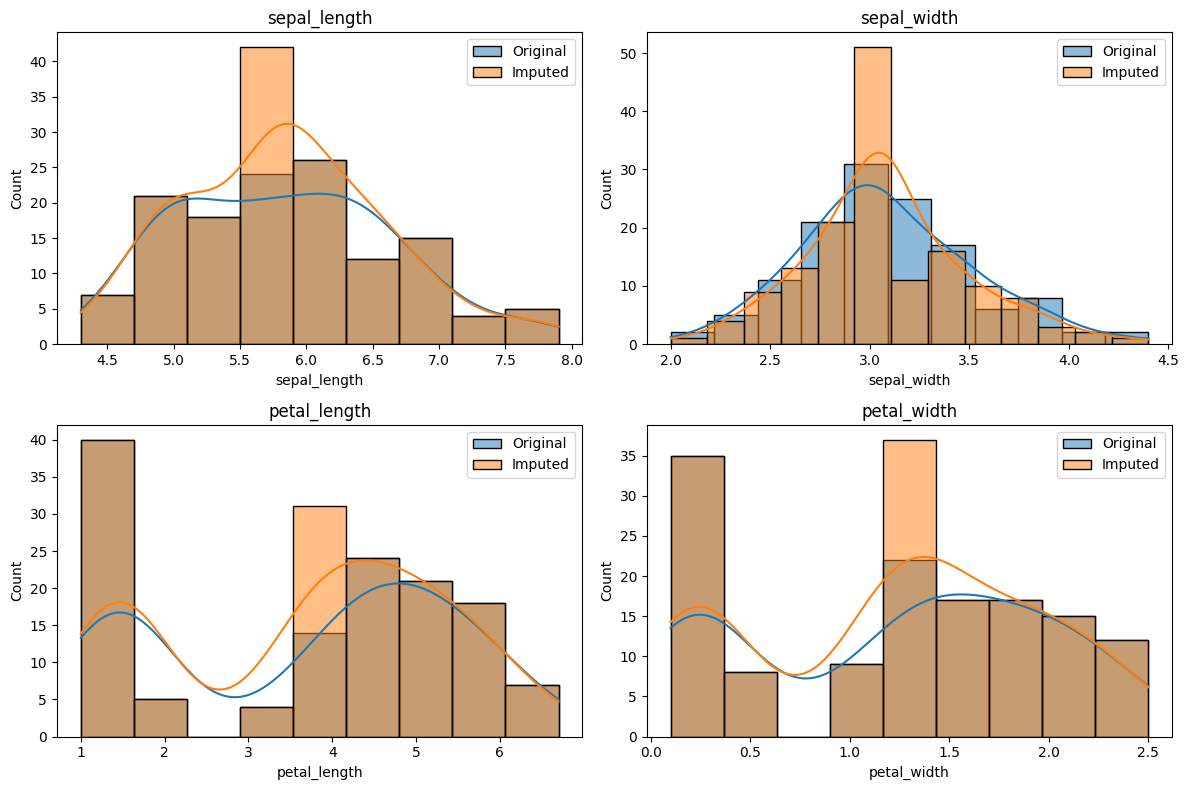

In [12]:
#평균값으로 대체 하고 비교하기
df_filled_mean = df.fillna(df.mean(numeric_only=True))

#그래프 설정
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()  # axes 배열을 1차원으로 변환

for i, col in enumerate(df.columns[:-1]):  # 'target' 컬럼 제외
    sns.histplot(df.iloc[:,i],
                 kde=True, color='C0', ax=axes[i], label='Original')
    sns.histplot(df_filled_mean.iloc[:,i],
                 kde=True, color='C1', ax=axes[i], label='Imputed')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

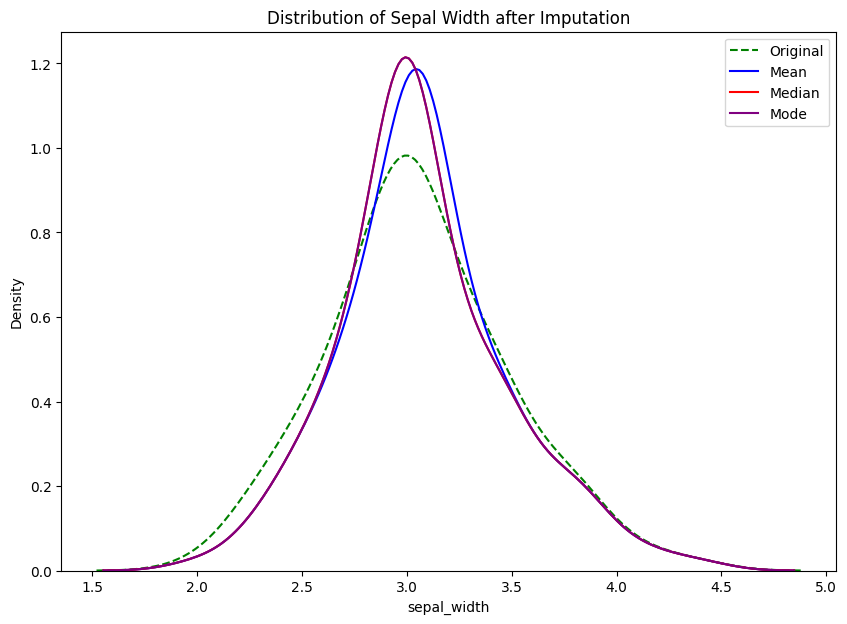

In [15]:
# 결측치 대체: 평균, 중앙, 최빈값
mean_filled = df.fillna(df.mean(numeric_only=True))
median_filled = df.fillna(df.median(numeric_only=True))
mode_filled = df.fillna(df.mode().iloc[0])

# 원본하고 비교해서 잘되었는지 확인하기
df_original  = sns.load_dataset('iris')

# 그래프 생성하기
plt.figure(figsize=(10, 7))
sns.kdeplot(df_original['sepal_width'], label='Original', color='green', linestyle='--')
sns.kdeplot(mean_filled['sepal_width'], label='Mean', color='blue')
sns.kdeplot(median_filled['sepal_width'], label='Median', color='red')
sns.kdeplot(mode_filled['sepal_width'], label='Mode', color='purple')
plt.legend()
plt.title('Distribution of Sepal Width after Imputation')
plt.show()

## 결측치 대체하기: KKN

In [19]:
from sklearn.impute import KNNImputer
import pandas as pd

# KNNImputer 객체 생성 및 적용 (오타 수정: uniform)
impouter  = KNNImputer(n_neighbors=5, weights='uniform')

# KNN은 숫자형 데이터만 처리 가능하므로 숫자형 컬럼만 추출
df_numeric = df.select_dtypes(include='number')

df_filled_knn = impouter.fit_transform(df_numeric)

# 변환된 데이터를 데이터프레임으로 변환
df_filled_knn = pd.DataFrame(df_filled_knn, columns=df_numeric.columns)

In [20]:
df_filled_knn.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.50,1.40,0.20
1,4.9,3.00,1.40,0.18
2,4.7,3.20,1.30,0.20
3,4.6,3.28,1.32,0.20
4,5.0,3.60,1.40,0.20


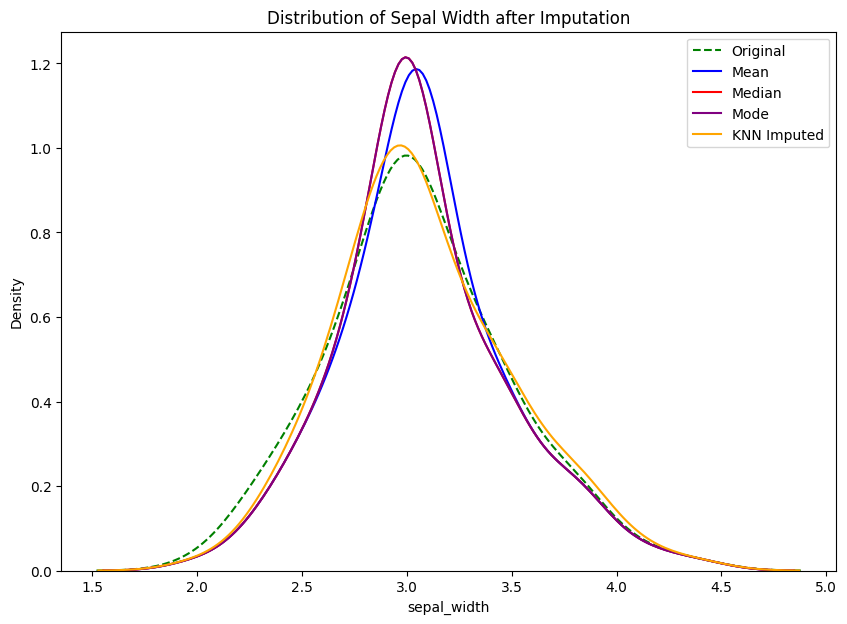

In [22]:
plt.figure(figsize=(10, 7))
sns.kdeplot(df_original['sepal_width'], label='Original', color='green', linestyle='--')
sns.kdeplot(mean_filled['sepal_width'], label='Mean', color='blue')
sns.kdeplot(median_filled['sepal_width'], label='Median', color='red')
sns.kdeplot(mode_filled['sepal_width'], label='Mode', color='purple')

sns.kdeplot(df_filled_knn['sepal_width'], label='KNN Imputed', color='orange')

plt.legend()
plt.title('Distribution of Sepal Width after Imputation')
plt.show()

In [24]:
df_original.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


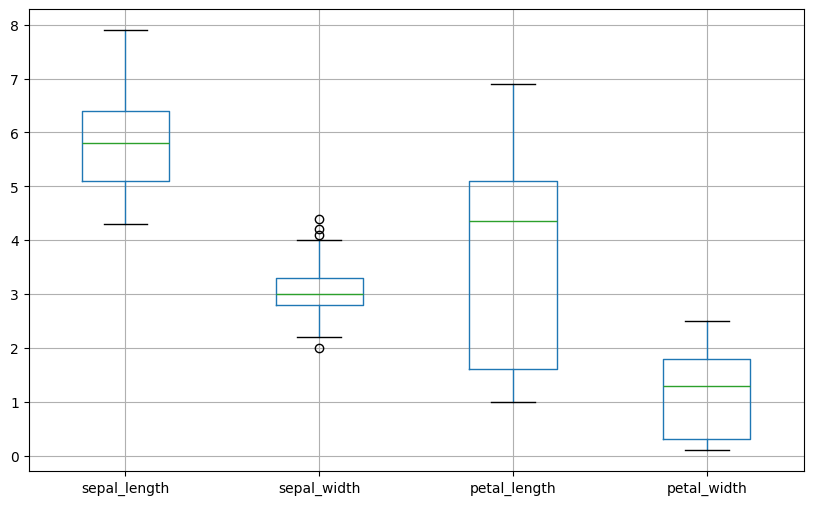

In [28]:
plt.figure(figsize=(10, 6))
df_original.boxplot()
plt.show()

##이상치 확인하기:LoF

In [29]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

clf = LocalOutlierFactor(n_neighbors = 5, # 이웃의 수 설정
                         contamination = 0.1)  # 이상치 비율 설정

df = df.dropna()

In [31]:
# 문자열 컬럼을 제외하고 숫자형 데이터만 추출
numeric_df = df.select_dtypes(include='number')

clf.fit_predict(numeric_df)
scores = clf.negative_outlier_factor_
scores

array([-1.00321723, -1.51229172, -1.25698056, -0.96834595, -1.10898619,
       -1.12668842, -1.5328425 , -0.98255238, -1.41543595, -1.82771711,
       -1.32647986, -1.18353325, -0.9635491 , -0.9959085 , -1.31136351,
       -2.07740744, -1.09374267, -1.38875908, -0.98421394, -1.24912019,
       -1.61322849, -1.42296797, -0.97724373, -1.309522  , -1.03105635,
       -1.23147337, -1.20113329, -0.97642499, -1.28869089, -0.99924366,
       -1.18562151, -0.97137171, -1.00117106, -1.00919695, -1.01462499,
       -0.99847203, -1.05803467, -1.19066367, -0.98326522, -1.02392291,
       -1.116405  , -0.98849138, -0.98326522, -1.76256621, -0.97951073,
       -1.04161438, -1.01619603, -1.97280196, -1.00585242, -1.26849094,
       -1.0119486 , -1.17699708, -1.02283572, -1.95435714, -1.29193242,
       -1.05862821, -0.9963562 , -0.94691124, -1.27418353, -1.20483116,
       -1.265882  , -1.00247227, -0.98217424, -1.28815916, -1.22893978,
       -0.96714105, -1.35400813, -1.10436059, -0.97343946, -0.96

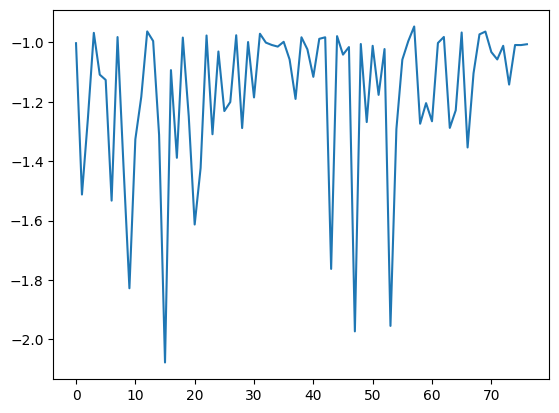

In [32]:
plt.plot(scores.tolist())

(array([ 1.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  2.,  0.,
         0.,  0.,  1.,  1.,  1.,  1.,  0.,  3.,  3.,  3.,  2.,  2.,  2.,
         4.,  0.,  1.,  3.,  2.,  0.,  4.,  5., 15., 11.,  5.]),
 array([-2.07740744, -2.05479752, -2.0321876 , -2.00957767, -1.98696775,
        -1.96435782, -1.9417479 , -1.91913798, -1.89652805, -1.87391813,
        -1.8513082 , -1.82869828, -1.80608835, -1.78347843, -1.76086851,
        -1.73825858, -1.71564866, -1.69303873, -1.67042881, -1.64781889,
        -1.62520896, -1.60259904, -1.57998911, -1.55737919, -1.53476927,
        -1.51215934, -1.48954942, -1.46693949, -1.44432957, -1.42171965,
        -1.39910972, -1.3764998 , -1.35388987, -1.33127995, -1.30867002,
        -1.2860601 , -1.26345018, -1.24084025, -1.21823033, -1.1956204 ,
        -1.17301048, -1.15040056, -1.12779063, -1.10518071, -1.08257078,
        -1.05996086, -1.03735094, -1.01474101, -0.99213109,

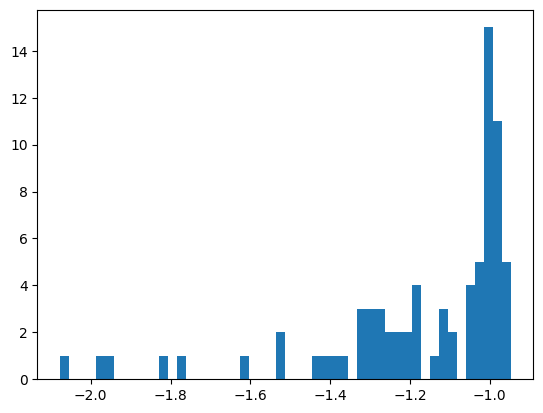

In [33]:
plt.hist(scores.tolist(), bins = 50 )

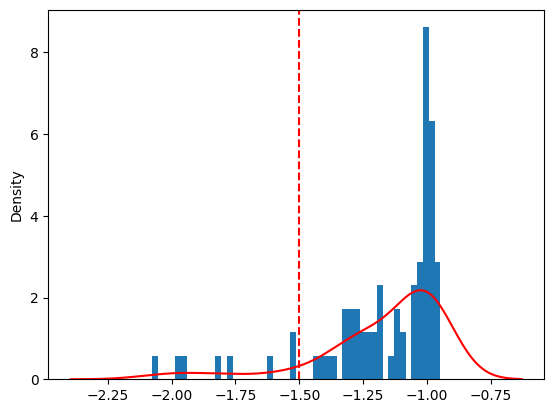

In [34]:
plt.hist(scores,
         bins = 50, # 막대 개수 설정
         density = True) # 밀도 플롯 설정

sns.kdeplot(scores,
            color = "r",
            ax = plt.gca())

plt.axvline(-1.5, color = 'red', linestyle='--') # 이상치 경계선

plt.show()

## 중복값 보기

In [35]:
duplicate = df.duplicated(keep = False)
df[duplicate]

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [36]:
df[~duplicate]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa
...,...,...,...,...,...
141,6.9,3.1,5.1,2.3,virginica
144,6.7,3.3,5.7,2.5,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
